In [ ]:
import os
import mne
import pandas as pd

from datasets import load_dataset
from huggingface_hub import snapshot_download
from matplotlib import pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

import warnings
warnings.filterwarnings("ignore")

In [ ]:
local_dir = snapshot_download(
    repo_id="zhuravlevahana/SIGNAL",
    repo_type="dataset",
    local_dir="../hf_old_datasets",
)

In [ ]:
local_dir = snapshot_download(
    repo_id="ContributorsSIGNAL/SIGNAL",
    repo_type="dataset",
    local_dir="../hf_datasets",
)

In [ ]:
eeg_foder = "../hf_datasets/eeg"

In [ ]:
event_counts = []
for file in sorted(os.listdir(eeg_foder)):
    if file.endswith(".fif"):
        epochs = mne.read_epochs(os.path.join(eeg_foder, file), preload=True)
        event_counts.append(len(epochs))

plt.figure(figsize=[5, 3])
plt.plot(event_counts)
plt.grid()
plt.title("Event counts")
plt.show()

### Про

In [ ]:
ds = load_dataset("ContributorsSIGNAL/SIGNAL", cache_dir="../hf_datasets")

In [ ]:
df = pd.read_csv("../hf_datasets/epochs_info/p0_events.csv")

In [ ]:
df

In [ ]:
df["event_name"]

In [ ]:
stimuli_df = pd.read_csv("../hf_datasets/stimuli.csv")

In [ ]:
stimuli_df

In [ ]:
mne.read_evokeds("../hf_datasets/eeg/p0_epochs.fif")

In [ ]:
epochs = mne.read_epochs("../hf_datasets/eeg/p0_epochs.fif", preload=True)

In [ ]:
epochs

In [ ]:
def build_erp_plot(required_stimuli: list[str],
                   times: list[float] = [-0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
                   epoch_folder: str = '../hf_datasets/eeg/'):
    required_stimuli_set = set(required_stimuli)

    evokeds = []

    for f in sorted(os.listdir(epoch_folder)):

        if not f.endswith('.fif'):
            continue

        epochs = mne.read_epochs(os.path.join(data_dir, f), preload=True)
        epochs_keys = set(epochs.event_id.keys())
        filtered_stimuli = epochs_keys.intersection(required_stimuli_set)
        combined_epochs = mne.concatenate_epochs([epochs[s] for s in filtered_stimuli])
        evoked = combined_epochs.average()
        evokeds.append(evoked)

    # считать отдельно у каждого человка

    if not evokeds:
        raise ValueError("Ни один участник не содержит указанных стимулов!")

    grand_avg = mne.grand_average(evokeds)
    grand_avg.plot()
    grand_avg.plot_topomap(times=times)


### Congruent Stimuli

In [ ]:
semantic_stimuli = [
    'Stimulus/S  1_1',
    'Stimulus/S  1_2',
    'Stimulus/S  1_3',
]

build_erp_plot(semantic_stimuli)

### Semantically Incongruent Stimuli ERP

In [ ]:
semantic_stimuli = [
    'Stimulus/S  2_1',
    'Stimulus/S  2_2',
    'Stimulus/S  2_3',
]

build_erp_plot(semantic_stimuli)

### Grammatically incongruen

In [ ]:
gram_stimuli = [
    'Stimulus/S  3_1',
    'Stimulus/S  3_2',
    'Stimulus/S  3_3',
]

build_erp_plot(gram_stimuli)

### Определение стимулов, оставшихся в ЭЭГ после фильтрации

In [ ]:
# С датасетом ContributorsSIGNAL/SIGNAL есть проблема
# 1) В файлах эпох лежат данные для испытуемых с отфильтрованными стимулами (<= 600 записей)
# 2) В файлах информациях об эпохах лежат данные обо всех стимулах (600) и их временные метки
# 3) Временные метки из .fif файлов не совпадают с метками из .csv

# Я взял датасет из черновика статьи zhuravlevahana/SIGNAL
# 1) для первых двух пациентов epoch_events совпали с epoch_info по колонке start
# 2) для остальных по колонке time2
# 3) это позволило получить связь с тем какие предложения остались в ЭЭГ после фильтрации, для дальнейшего анализа (например построения RSA)

### Видимо, формат файлов epoch_info для чернового варианта набора данных менялся, а вот .fif файлы
### похоже переносились без изменений, поэтому сейчас итоговоый набор данных не совсем валиден

def align_events(dataset_folder: str, aligned_files_output: str) -> None:
    os.makedirs(aligned_files_output, exist_ok=True)

    xlsx_files = []
    fif_files = []
    for file_name in os.listdir(dataset_folder):
        if str(file_name).endswith(".xlsx"):
            xlsx_files.append(str(os.path.join(dataset_folder, file_name)))
        if str(file_name).endswith(".fif"):
            fif_files.append(str(os.path.join(dataset_folder, file_name)))

    fif_p_dict: dict[str, str] = {}
    for file_name in fif_files:
        fif_p_name = file_name.split("/")[-1].split("_")[0]
        fif_p_dict[fif_p_name] = file_name

    for xlsx_file in xlsx_files:
        xlsx_p_name = xlsx_file.split("/")[-1].split("_")[0]
        fif_file = fif_p_dict[xlsx_p_name]

        print(xlsx_file, fif_file)

        if xlsx_p_name in {"p0", "p1"}:
            col = "start"
        else:
            col = "time2"

        xlsx_df = pd.read_excel(xlsx_file)
        from ast import literal_eval
        xlsx_df["sentence_combined"] = xlsx_df["sentence"].apply(lambda x: " ".join(literal_eval(x)))

        epoch = mne.read_epochs(fif_file, preload=True)
        event_id_dict = dict(epoch.event_id)
        epochs_events = pd.DataFrame(epoch.events, columns=[col, "1", "event_id"])

        try:
            merged_df = epochs_events.merge(xlsx_df, how="left", on=col)
        except Exception as e:
            print(e)
            print(xlsx_file)
            break

        for i, row in merged_df.iterrows():
            stimuli_id = row["event_id"]
            stimuli_name = row["name"]
            if event_id_dict[stimuli_name] != int(stimuli_id):
                print(row)
                raise RuntimeError("Stimuli are not equal!")

        merged_df = merged_df.rename(columns={col: "event_time"})
        merged_df.to_csv(aligned_files_output + "/" + f"{xlsx_p_name}_aligned.csv", index=False)



align_events("../hf_old_datasets", "../epochs_eeg_aligned")

В наборе данных по одному trial на предложение для каждого участника. Мы не можем получить ERP для конкретного стимула по каждому участнику

In [23]:
from mne import EvokedArray

def get_erp_by_sentence(
    sentence: str,
    dataset_dir: str,
    aligned_files_dir: str,
) -> EvokedArray:

    epoch_index_dict: dict[str, int] = dict()

    total_epoch_files_processed: int = 0

    for file_name in os.listdir(aligned_files_dir):

        total_epoch_files_processed += 1

        aligned_df = pd.read_csv(aligned_files_dir + "/" + file_name)
        matching_indices = aligned_df[aligned_df['sentence_combined'] == sentence].index.tolist()
        if len(matching_indices) > 1:
            raise RuntimeError("Duplicate sentence found in aligned file!")
        if len(matching_indices) == 0:
            continue

        index_value = matching_indices[0]

        epoch_name = file_name.split("_")[0]
        epoch_index_dict[epoch_name] = index_value

    print(f"Sentence found in {len(epoch_index_dict.keys())} of {total_epoch_files_processed}")

    epochs_for_averaging = []

    for key, value in epoch_index_dict.items():
        for file_name in os.listdir(dataset_dir):
            if file_name.endswith(".fif") and f"{key}_epochs" in file_name:
                ep = mne.read_epochs(dataset_dir + "/" + file_name, preload=True)
                stimuli = ep[value].average()
                epochs_for_averaging.append(stimuli)

    return mne.grand_average(epochs_for_averaging)

In [55]:
epoch_index_dict

NameError: name 'epoch_index_dict' is not defined

In [24]:
roi_dict = {
    "all": [],
    "central_parietal": ['Cz', 'CPz', 'Pz', 'CP1', 'CP2', 'P3', 'P4'],  # N400
    "posterior_parietal": ['Pz', 'POz', 'P3', 'P4', 'O1', 'O2'],        # P600
}

In [25]:
stimuli_df = pd.read_csv("../hf_datasets/stimuli.csv")
stimuli_df.head()

sentence: str = str(stimuli_df.iloc[599]["sentence"])

print(sentence)

ev_arr = get_erp_by_sentence(
    sentence=sentence,
    dataset_dir="../hf_old_datasets",
    aligned_files_dir="../epochs_eeg_aligned",
)

Эксперты сделали вывода
Sentence found in 20 of 21
Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_old_datasets/p5_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available
Not setting metadata
587 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_old_datasets/p14_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available
Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_old_datasets/p9_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available
Not setting metadata
594 matching events found
No bas

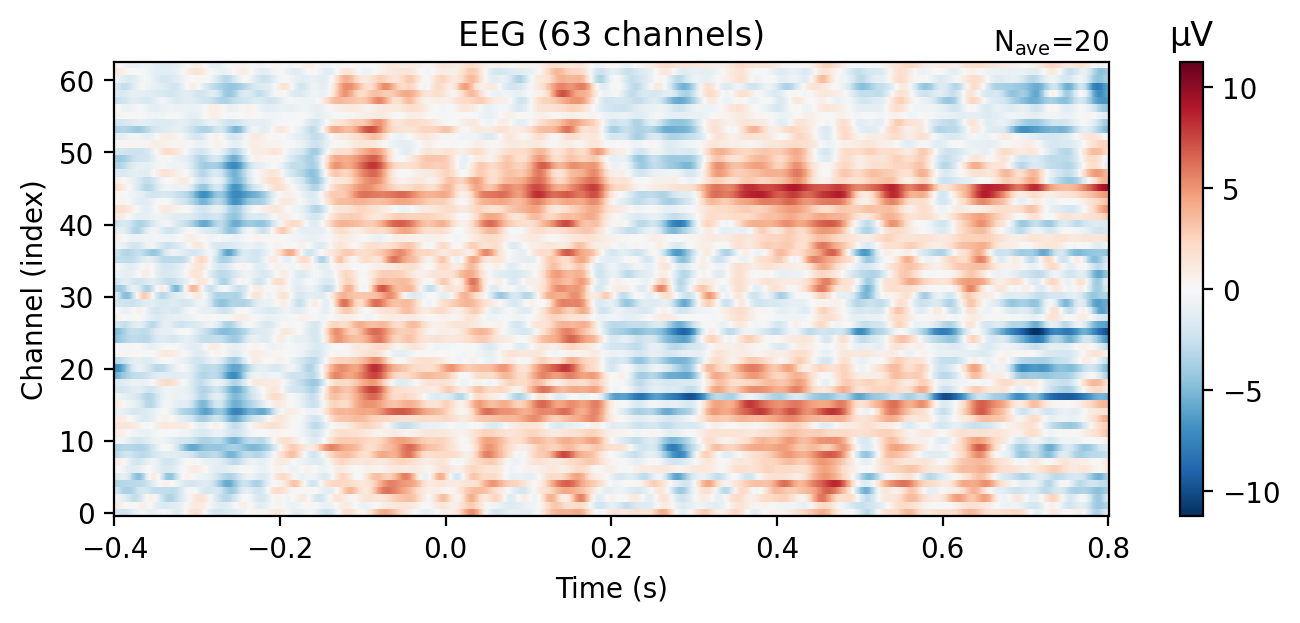

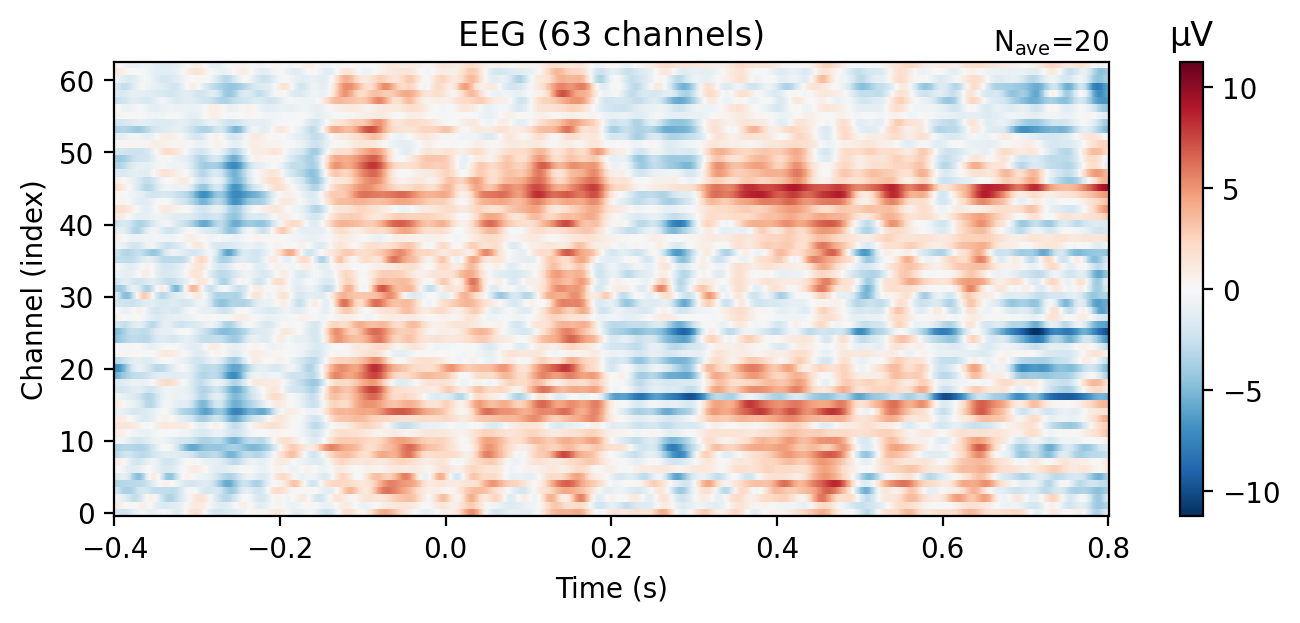

In [39]:
ev_arr.plot_image()

eps = [f"p{i}" for i in range(len(aligned_df_dict.keys()))]

In [53]:
arrs = []

for ep in eps:
    d: pd.DataFrame = aligned_df_dict[ep]
    indexes = d.set_index("sentence_combined").index.get_indexer(stimuli_df["sentence"])
    break

In [56]:
len(indexes)

600

In [77]:
import numpy as np

preloaded_epochs_dict["p0"].get_data().shape

(579, 63, 1201)

In [1]:
from src.eeg_utils import get_eeg_for_all_sentences

for_all_sentences = get_eeg_for_all_sentences(
    sentences=stimuli_df["sentence"],
    dataset_dir="../hf_old_datasets",
    aligned_files_dir="../epochs_eeg_aligned",
)

NameError: name 'stimuli_df' is not defined

NameError: name 'get_eeg_for_all_sentences' is not defined